In [15]:
TICKER = "2330.TW"
START_TIME = "2020-01-01"
INTERVAL = "1d"
FEATURES = ["Close"]
SEQ_LEN = 30

In [16]:
from datetime import datetime, timedelta
import yfinance as yf
import pandas as pd
import ta


start_time = datetime.strptime(START_TIME, "%Y-%m-%d")
start_time_prev = start_time - timedelta(days=SEQ_LEN * 2)
end_time_prev = start_time - timedelta(days=1)

df = yf.download(
    TICKER,
    start=START_TIME,
    end="2025-12-31",
    interval=INTERVAL,
)
df_prev = yf.download(
    TICKER,
    start=start_time_prev,
    end=end_time_prev,
    interval=INTERVAL,
)
if df is None or df.empty or df_prev is None or df_prev.empty:
    raise ValueError("Failed to download train data")

df_all = pd.concat([df_prev, df])
df_all.columns = df_all.columns.droplevel(1)
df_all = ta.add_all_ta_features(
    df_all, open="Open", high="High", low="Low", close="Close", volume="Volume"
)

print(df_all.columns)

df_prev, df = df_all[:START_TIME], df_all[START_TIME:]
data_prev, data = df_prev[FEATURES].to_numpy(), df[FEATURES].to_numpy()

print(data_prev.shape, data.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'volume_adi', 'volume_obv',
       'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt',
       'volume_vwap', 'volume_mfi', 'volume_nvi', 'volatility_bbm',
       'volatility_bbh', 'volatility_bbl', 'volatility_bbw', 'volatility_bbp',
       'volatility_bbhi', 'volatility_bbli', 'volatility_kcc',
       'volatility_kch', 'volatility_kcl', 'volatility_kcw', 'volatility_kcp',
       'volatility_kchi', 'volatility_kcli', 'volatility_dcl',
       'volatility_dch', 'volatility_dcm', 'volatility_dcw', 'volatility_dcp',
       'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal',
       'trend_macd_diff', 'trend_sma_fast', 'trend_sma_slow', 'trend_ema_fast',
       'trend_ema_slow', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg',
       'trend_vortex_ind_diff', 'trend_trix', 'trend_mass_index', 'trend_dpo',
       'trend_kst', 'trend_kst_sig', 'trend_kst_diff', 'trend_ichimoku_conv',
       'trend_ichimoku_base

In [17]:
split = int(len(data) * 0.8)
train, test = data[:split], data[split:]

print(train.shape, test.shape)

(1164, 1) (292, 1)


In [18]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np


scaler = MinMaxScaler()
scaler.fit(np.concatenate((data_prev, train)))

data_prev_scaled = scaler.transform(data_prev)
train_scaled = scaler.transform(train)
test_scaled = scaler.transform(test)

In [19]:
import numpy as np


def create_sequences(data, seq_len=60, data_prev=None):
    X, y = [], []
    if data_prev is not None:
        data = np.concatenate((data_prev[-seq_len:], data))
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len : i])
        y.append(data[i, 0])
    return np.array(X), np.array(y).reshape(-1, 1)


X_train, y_train = create_sequences(train_scaled, SEQ_LEN, data_prev)
X_test, y_test = create_sequences(test_scaled, SEQ_LEN, train_scaled)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1164, 30, 1) (1164, 1)
(292, 30, 1) (292, 1)


In [20]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import (
    MultiHeadAttention,
    LayerNormalization,
    Input,
    LSTM,
    Dropout,
    GlobalAveragePooling1D,
    Dense,
)


tf.keras.backend.clear_session()


class SelfAttentionBlock(tf.keras.layers.Layer):
    def __init__(self, num_heads=4, key_dim=16, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim, dropout=dropout
        )
        self.norm = LayerNormalization()

    def call(self, x):
        attn = self.mha(x, x)
        return self.norm(x + attn)


model = Sequential(
    [
        Input(shape=(SEQ_LEN, len(FEATURES))),
        # LSTM(64, return_sequences=True),
        # Dropout(0.2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        # LSTM(64, return_sequences=True),
        # Dropout(0.2),
        # SelfAttentionBlock(num_heads=4, key_dim=16, dropout=0.1),
        # GlobalAveragePooling1D(),
        # Dense(32, activation="relu"),
        Dense(1),
    ]
)

model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
    ],
)

print("***** Training Completed *****")

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0224 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0033 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0026 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0020 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 10/1

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


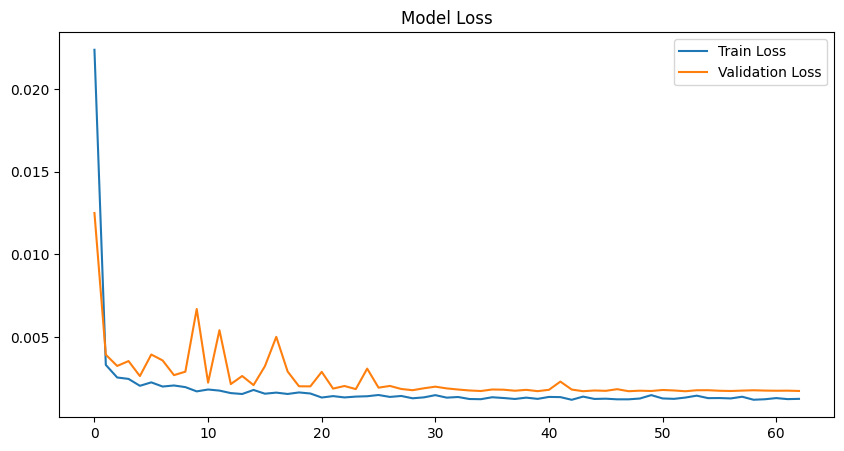

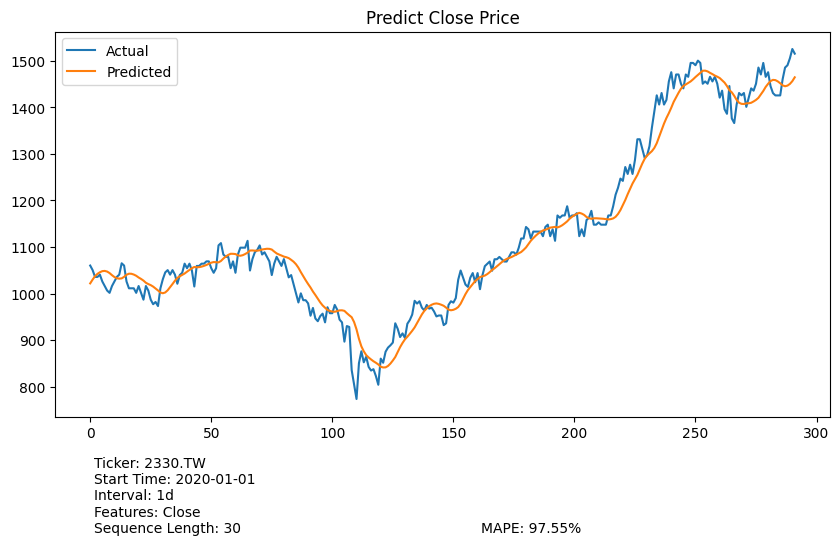

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error


y_pred = model.predict(X_test)
dummy_pred = np.zeros((len(y_pred), len(FEATURES)))
dummy_test = np.zeros((len(y_pred), len(FEATURES)))
dummy_pred[:, 0] = y_pred[:, 0]
dummy_test[:, 0] = y_test[:, 0]

y_pred_inv = scaler.inverse_transform(dummy_pred)[:, 0]
y_test_inv = scaler.inverse_transform(dummy_test)[:, 0]

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label="Actual")
plt.plot(y_pred_inv, label="Predicted")
plt.title("Predict Close Price")
plt.legend()
plt.text(
    0.05,
    -0.3,
    f"Ticker: {TICKER}\nStart Time: {START_TIME}\nInterval: {INTERVAL}\nFeatures: {','.join(FEATURES)}\nSequence Length: {SEQ_LEN}",
    transform=plt.gca().transAxes,
)
plt.text(
    0.55,
    -0.3,
    f"MAPE: {1 - mean_absolute_percentage_error(y_test_inv, y_pred_inv):.2%}",
    transform=plt.gca().transAxes,
)
plt.savefig(
    f'output/{datetime.now().strftime("%Y%m%d_%H%M%S")}_{TICKER}_pred.png',
    bbox_inches="tight",
)
plt.show()